# **1. Perkenalan Dataset**


**Nama Dataset: Bank Transaction Dataset for Fraud Dete**

1. Sumber Dataset:
   - Dataset berasal dari Kaggle, salah satu public repository yang menyediakan berbagai dataset untuk analisis data dan machine learning.

3. Ketentuan Dataset:

- Tanpa label: Dataset ini tidak memiliki kolom label atau kelas yang menentukan apakah sebuah transaksi adalah penipuan atau bukan, sehingga sesuai untuk tugas unsupervised learning seperti anomaly detection.
- Jumlah Baris: Dataset memiliki 2.512 baris, yang memenuhi syarat minimal 1.000 baris.
- Tipe Data:
    - Kategorikal:
        - TransactionType (Credit/Debit)
        - Location (Nama kota di AS)
        - Channel (Online, ATM, Branch)
        - CustomerOccupation (Doctor, Engineer, Student, Retired)

    - Numerikal:
        - TransactionAmount (Nilai transaksi)
        - AccountBalance (Saldo akun setelah transaksi)
        - TransactionDuration (Durasi transaksi dalam detik)
        - CustomerAge (Usia pemilik akun)
        - LoginAttempts (Jumlah percobaan login sebelum transaksi)

3. Pembatasan:
    - Dataset ini tidak digunakan dalam latihan clustering customer segmentation, karena lebih berfokus pada pola transaksi keuangan dan potensi deteksi anomali.
    - Dataset ini cocok untuk analisis anomaly detection atau fraud detection dalam konteks financial security.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = '/content/drive/MyDrive/Submission/bank_transactions_data.csv'

df = pd.read_csv(data)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# 1. Memahami Struktur Data
print("\n=== Struktur Data ===")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)


=== Struktur Data ===
Shape: (2512, 16)

Data types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object


In [ ]:
# 2. Menangani Data yang Hilang
print("Jumlah Data yang Hilang:\n", df.isnull().sum())

Jumlah Data yang Hilang:
 TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


In [ ]:
# Statistik deskriptif untuk data numerik
print("\nStatistik deskriptif data numerik:")
df.describe()


Statistik deskriptif data numerik:


,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


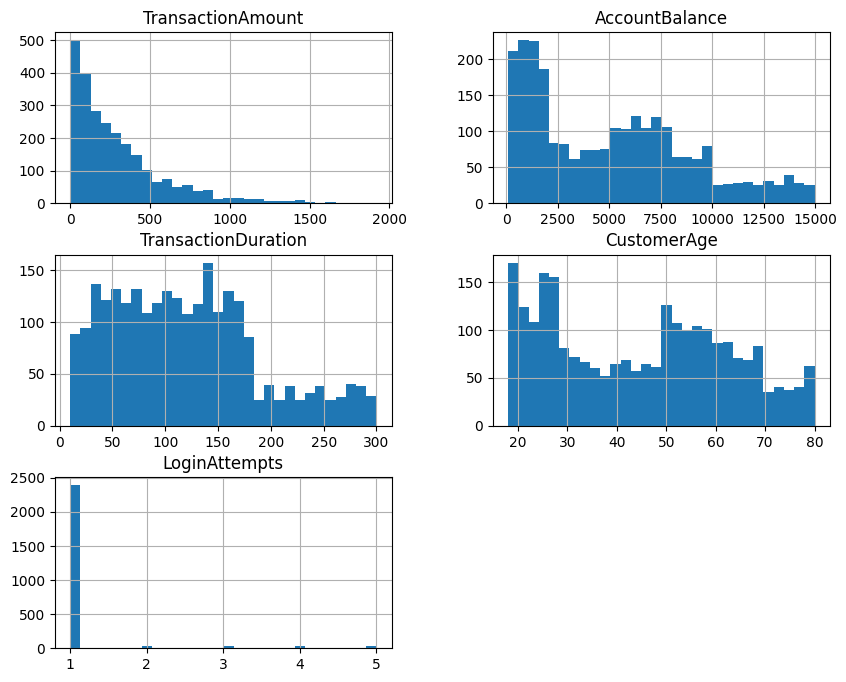

In [ ]:
# Visualisasi distribusi data numerik
numerical_features = ["TransactionAmount", "AccountBalance", "TransactionDuration", "CustomerAge", "LoginAttempts"]
df[numerical_features].hist(figsize=(10, 8), bins=30)
plt.show()

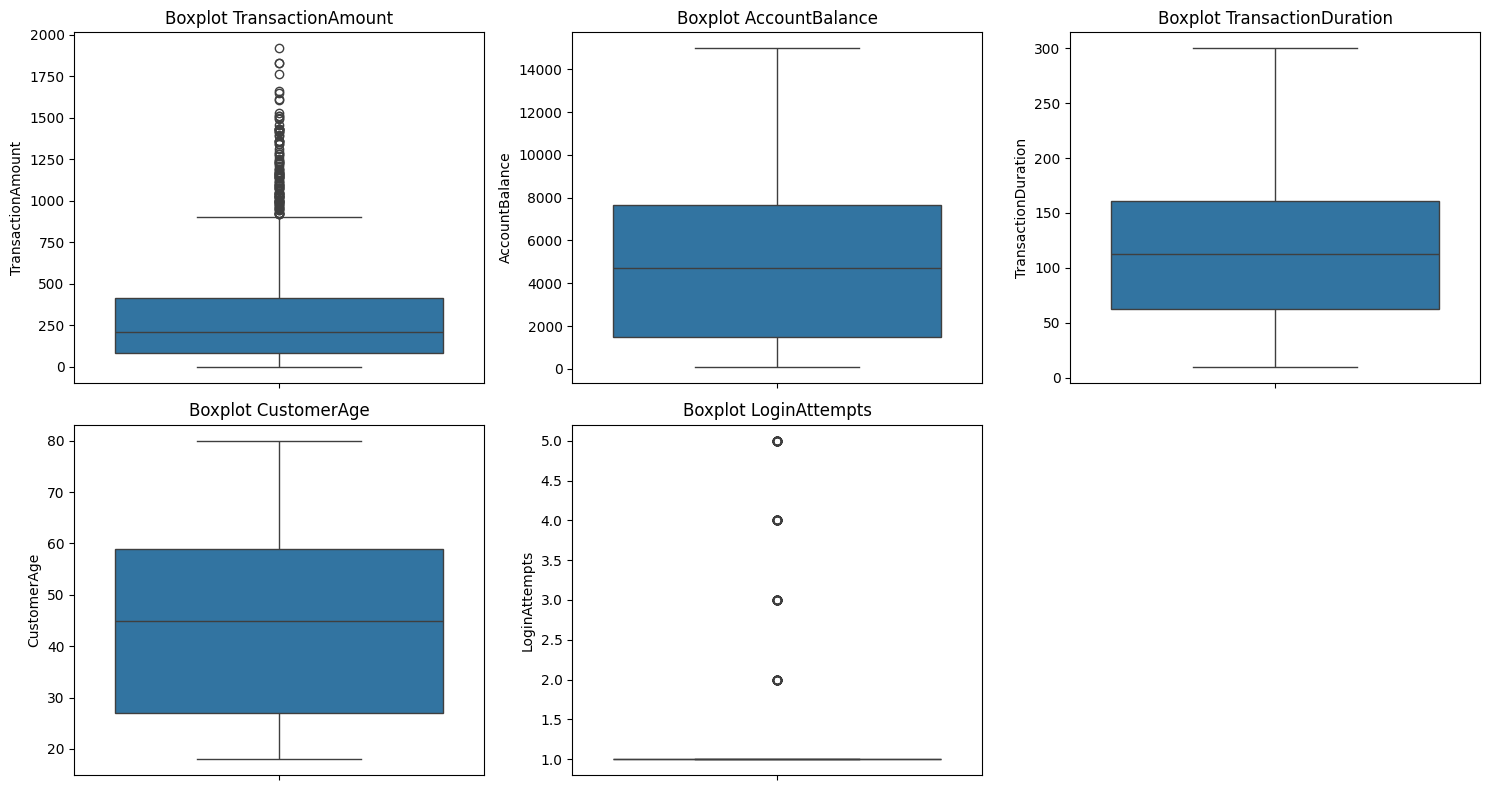

In [ ]:
# Boxplot untuk outlier
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

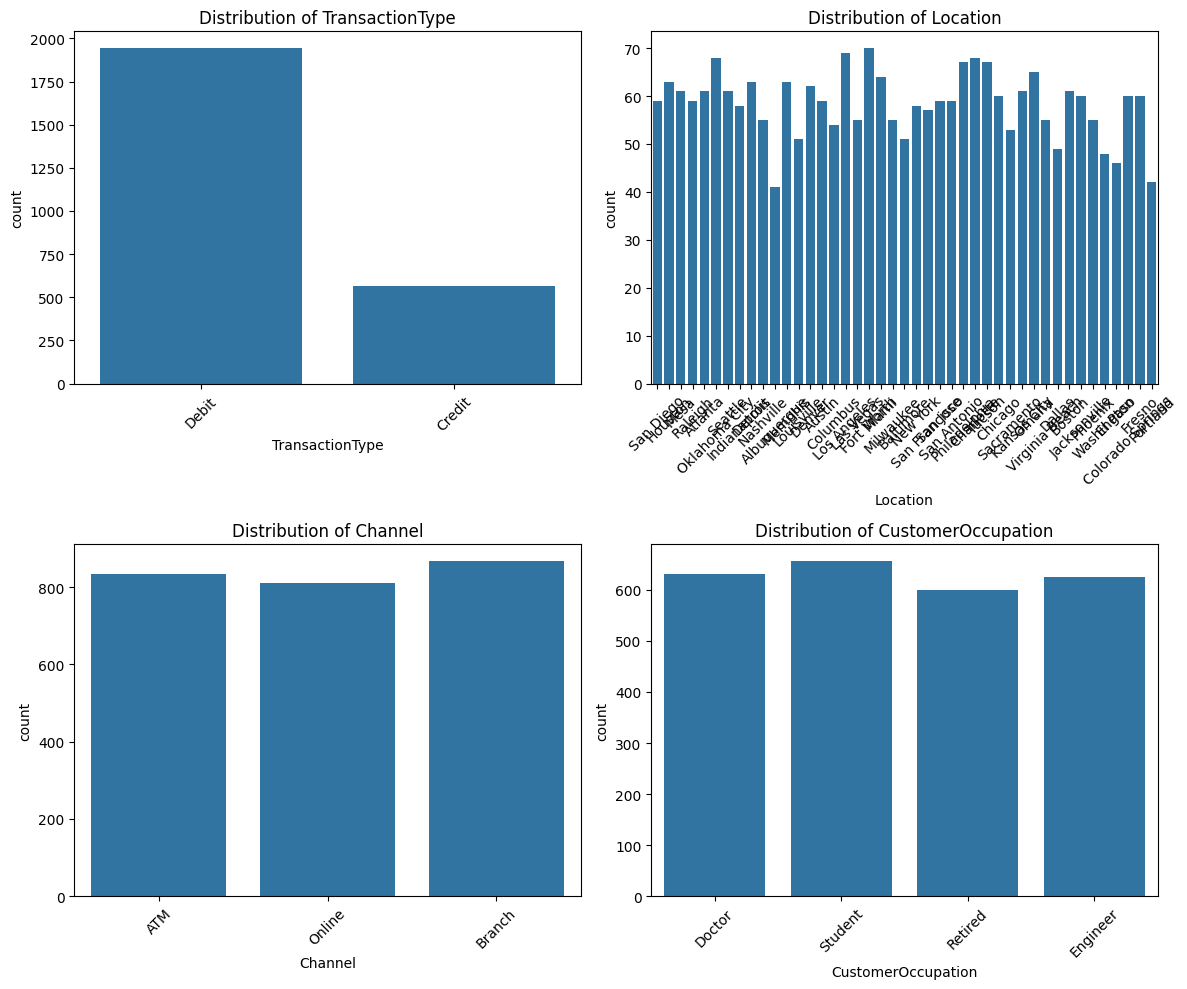

In [ ]:
# Visualisasi distribusi data kategorikal
categorical_features = ["TransactionType", "Location", "Channel", "CustomerOccupation"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

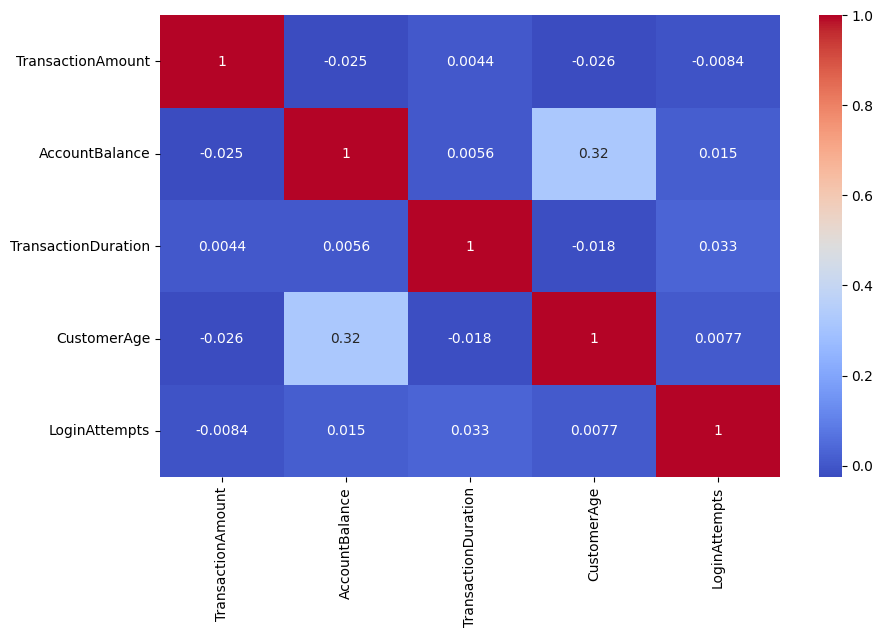

In [ ]:
# Heatmap korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [ ]:
# Mengecek jumlah missing value di setiap kolom
missing_values = df.isnull().sum()
print("Jumlah missing value di setiap kolom:")
print(missing_values)

Jumlah missing value di setiap kolom:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


In [ ]:
# Menghapus Data Duplikat
# Identifikasi
print("\nJumlah data duplikat:", df.duplicated().sum())


Jumlah data duplikat: 0


In [ ]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Pilih kolom numerik yang akan distandarisasi
numerical_cols = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 'CustomerAge', 'LoginAttempts']

# Fit & transform
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Simpan scaler asli
original_scaler = scaler

# Cetak hasil yang benar
print("\nData setelah standarisasi:")
print(df[numerical_cols].shape)


Data setelah standarisasi:
(2512, 5)


In [ ]:
# Kolom numerik
numerical_cols = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 'CustomerAge', 'LoginAttempts']

# Deteksi outlier sebelum standarisasi
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Filter outlier sebelum standarisasi
df = df[~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

# Standarisasi hanya pada data yang sudah bersih dari outlier
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("\nJumlah data setelah handling outlier:", len(df))


Jumlah data setelah handling outlier: 2282


In [ ]:
# Encoding data kategorikal
# Kolom kategorikal
categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

# Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Simpan encoder untuk inverse transform nanti

print("\nData setelah encoding:")
print(df[categorical_cols].head())


Data setelah encoding:
   TransactionType  Location  Channel  CustomerOccupation
0                1        36        0                   0
1                1        15        0                   0
2                1        23        2                   3
3                1        33        2                   3
4                0         1        2                   3


In [ ]:
#Binning (Pengelompokan Data)
# binning untuk CustomerAge
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])

df['CustomerAge_Original'] = df['CustomerAge']
print("\nData setelah binning AgeGroup:")
print(df[['CustomerAge', 'AgeGroup']].head())


Data setelah binning AgeGroup:
   CustomerAge AgeGroup
0     1.429702    Young
1     1.316759    Young
2    -1.450340      NaN
3    -1.055040      NaN
4    -1.055040      NaN


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [ ]:
# Pembangunan Model Clustering

# Pilih fitur untuk clustering
selected_features = ['TransactionAmount', 'Channel', 'CustomerOccupation', 'CustomerAge', 'LoginAttempts']
X = df[selected_features]

X_scaled = df[selected_features].values

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

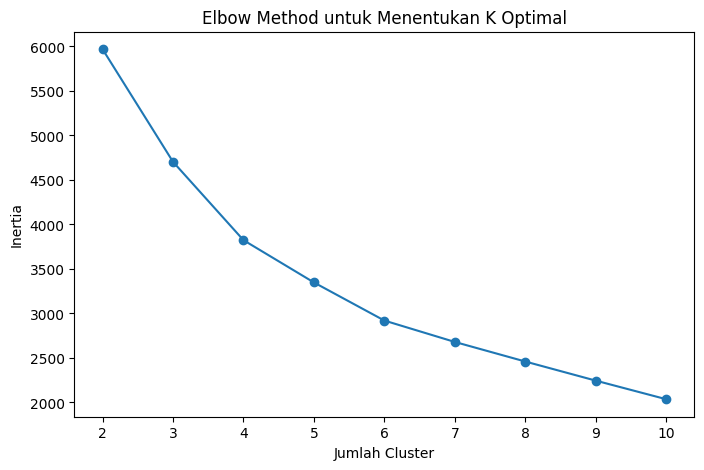

In [ ]:
# Menentukan jumlah cluster optimal dengan Elbow Method
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()

In [ ]:
## Latih model K-Means dengan jumlah cluster optimal
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Hitung Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, labels_kmeans)
print(f'Silhouette Score untuk {n_clusters} Cluster: {silhouette_avg:.2f}')

Silhouette Score untuk 5 Cluster: 0.32


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [ ]:
# Definisikan all_features
all_features = numerical_cols + categorical_cols

# --- Feature Scaling ---
# Skalakan fitur numerik ke dalam rentang tertentu (misalnya, 0-1) menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(df[all_features])


# --- Feature Selection using VarianceThreshold ---
# Hapus fitur dengan varians rendah
selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(X_all_scaled)


# --- Get selected feature names ---
# Dapatkan indeks fitur yang terpilih
selected_feature_indices = selector.get_support(indices=True)
# Dapatkan nama fitur yang terpilih
selected_features = df[all_features].columns[selected_feature_indices]

print("\nFitur terpilih dengan VarianceThreshold:")
print(selected_features)


Fitur terpilih dengan VarianceThreshold:
Index(['TransactionType', 'Channel', 'CustomerOccupation'], dtype='object')



Elbow Method dengan fitur terpilih...


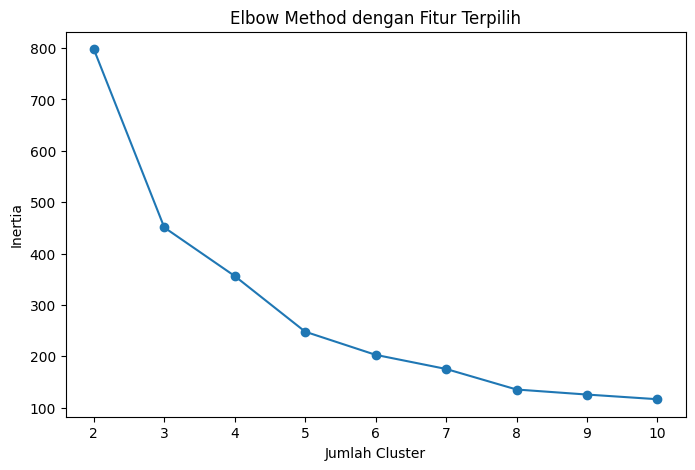

In [ ]:
# 2. Pemodelan dengan Fitur Terpilih

X_selected_np = X_selected  # Assuming X_selected is a NumPy array

# Elbow Method untuk menentukan K optimal dengan fitur terpilih
print("\nElbow Method dengan fitur terpilih...")
inertia_selected = []
for k in range(2, 11):
    kmeans_selected = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_selected.fit(X_selected_np)
    inertia_selected.append(kmeans_selected.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia_selected, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method dengan Fitur Terpilih')
plt.show()

In [ ]:
# Latih model dengan fitur terpilih (gunakan jumlah cluster optimal)
print("\nMelatih model dengan fitur terpilih...")
optimal_n_clusters = 5  # Replace with the optimal number of clusters from Elbow method
kmeans_selected = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init='auto')
labels_selected = kmeans_selected.fit_predict(X_selected_np)

# Hitung Silhouette Score
silhouette_selected = silhouette_score(X_selected_np, labels_selected)
print(f"\nSilhouette Score dengan fitur terpilih: {silhouette_selected:.2f}")


Melatih model dengan fitur terpilih...

Silhouette Score dengan fitur terpilih: 0.51


In [ ]:
# 3. Perbandingan Performa

print("\n=== Perbandingan Performa ===")
print(f"Silhouette Score sebelum feature selection: {silhouette_avg:.2f}")
print(f"Silhouette Score setelah feature selection: {silhouette_selected:.2f}")

# Analisis cluster dengan fitur terpilih
df['Cluster_Selected'] = labels_selected

# Tampilkan contoh hasil clustering dengan fitur terpilih
print("\nContoh data dengan hasil clustering (fitur terpilih):")
print(df[selected_features.tolist() + ['Cluster_Selected']].head())


=== Perbandingan Performa ===
Silhouette Score sebelum feature selection: 0.32
Silhouette Score setelah feature selection: 0.51

Contoh data dengan hasil clustering (fitur terpilih):
   TransactionType  Channel  CustomerOccupation  Cluster_Selected
0                1        0                   0                 3
1                1        0                   0                 3
2                1        2                   3                 0
3                1        2                   3                 0
4                0        2                   3                 2


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

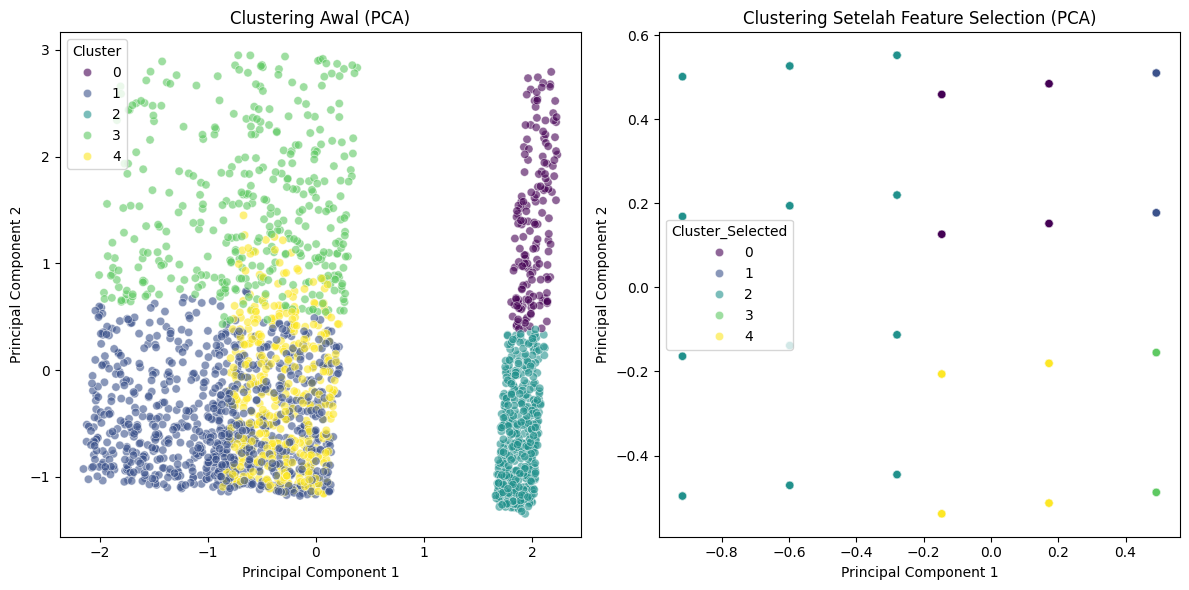

In [ ]:
# === 1. REDUKSI DIMENSI DENGAN PCA ===
pca = PCA(n_components=2)

# PCA untuk data sebelum feature selection (menggunakan X_scaled)
X_pca = pca.fit_transform(X_scaled)

# PCA untuk data setelah feature selection (menggunakan X_selected_np)
X_selected_pca = pca.fit_transform(X_selected_np)

# === 2. UPDATE 'Cluster' COLUMN ===

df['Cluster'] = kmeans.labels_  # Update with latest cluster labels

# === 3. VISUALISASI ===
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Plot 1: Clustering Awal ---
sns.scatterplot(ax=axes[0], x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'],
                palette='viridis', alpha=0.6)
axes[0].set_title('Clustering Awal (PCA)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# --- Plot 2: Clustering Setelah Feature Selection ---
sns.scatterplot(ax=axes[1], x=X_selected_pca[:, 0], y=X_selected_pca[:, 1], hue=df['Cluster_Selected'],
                palette='viridis', alpha=0.6)
axes[1].set_title('Clustering Setelah Feature Selection (PCA)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [ ]:
# Tambahkan label cluster ke DataFrame yang sudah dinormalisasi
df_normalized = df.copy()
df_normalized['Cluster'] = kmeans.labels_

# Gabungkan dengan data asli (untuk interpretasi)
df['Cluster'] = kmeans.labels_

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [ ]:
# Inverse transform untuk data numerik
numerical_cols = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 'CustomerAge', 'LoginAttempts']
# Gunakan original_scaler untuk inverse transform
df[numerical_cols] = original_scaler.inverse_transform(df[numerical_cols])
print("\nData numerik setelah inverse transform:")
print(df[numerical_cols].head())


Data numerik setelah inverse transform:
   TransactionAmount  AccountBalance  TransactionDuration  CustomerAge  \
0              14.09         5112.21                 81.0         70.0   
1             376.24        13758.91                141.0         68.0   
2             126.29         1122.35                 56.0         19.0   
3             184.50         8569.06                 25.0         26.0   
4              13.45         7429.40                198.0         26.0   

   LoginAttempts  
0            1.0  
1            1.0  
2            1.0  
3            1.0  
4            1.0  


In [ ]:
# Inverse transform untuk data kategorikal
for col in categorical_cols:
    df[col] = label_encoders[col].inverse_transform(df[col])

print("\nData setelah inverse encoding:")
print(df[categorical_cols].head())


Data setelah inverse encoding:
  TransactionType   Location Channel CustomerOccupation
0           Debit  San Diego     ATM             Doctor
1           Debit    Houston     ATM             Doctor
2           Debit       Mesa  Online            Student
3           Debit    Raleigh  Online            Student
4          Credit    Atlanta  Online            Student


In [ ]:
# Rekonstruksi AgeGroup dari CustomerAge asli
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=[0, 30, 50, 100], labels=['Young', 'Middle-aged', 'Senior'])
print("\nData AgeGroup setelah rekonstruksi:")
print(df[['CustomerAge', 'AgeGroup']].head())  # Menampilkan 5 baris pertama AgeGroup


Data AgeGroup setelah rekonstruksi:
   CustomerAge AgeGroup
0         70.0   Senior
1         68.0   Senior
2         19.0    Young
3         26.0    Young
4         26.0    Young


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

Profil Cluster:


TransactionAmount                                 AccountBalance  \
                     mean  median     min     max     std           mean   
Cluster                                                                    
0                  587.62  581.65  365.43  903.19  150.98        1658.87   
1                  143.60  121.30    0.32  414.77  103.24        7149.45   
2                  150.54  134.97    0.26  376.78  102.63        1553.57   
3                  572.93  540.96  334.07  896.79  151.43        6788.05   
4                  181.96  162.59    1.21  557.41  134.95        4620.05   

                                              ... LoginAttempts              \
          median      min       max      std  ...          mean median  min   
Cluster                                       ...                             
0        1044.33   102.20   9951.68  2127.07  ...           1.0    1.0  1.0   
1        7255.41   112.76  14942.78  3903.20  ...           1.0    1.0  1.0   
2        1096.78   101.25   9716.68  1838.51  ...           1.0    1.0  1.0   
3        6599.54   207.10  14977.99  3744.08  ...           1.0    1.0  1.0   
4        4673.28  1006.12   7996.70  2043.46  ...           1.0    1.0  1.0   

                  TransactionType     Location  Channel CustomerOccupation  \
         max  std        <lambda>     <lambda> <lambda>           <lambda>   
Cluster                                                                      
0        1.0  0.0           Debit  Los Angeles      ATM            Student   
1        1.0  0.0           Debit    San Diego   Branch             Doctor   
2        1.0  0.0           Debit        Miami   Branch            Student   
3        1.0  0.0           Debit      Houston      ATM           Engineer   
4        1.0  0.0           Debit      Houston      ATM            Retired   

            AgeGroup  
            <lambda>  
Cluster               
0              Young  
1        Middle-aged  
2              Young  
3             Senior  
4             Senior  

[5 rows x 30 columns]

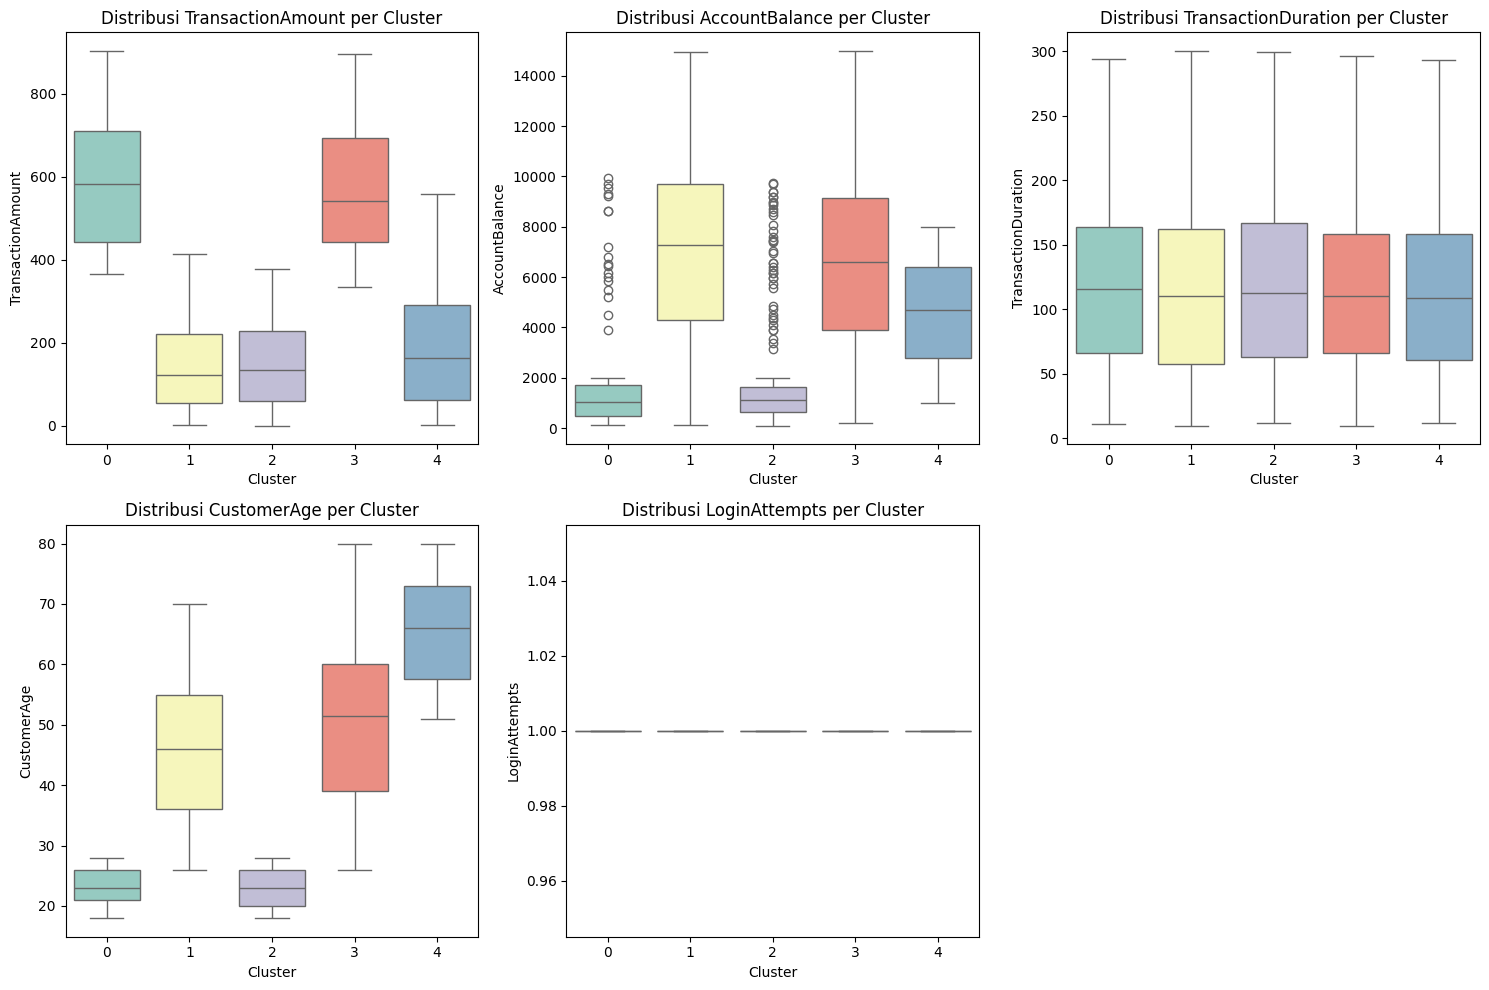

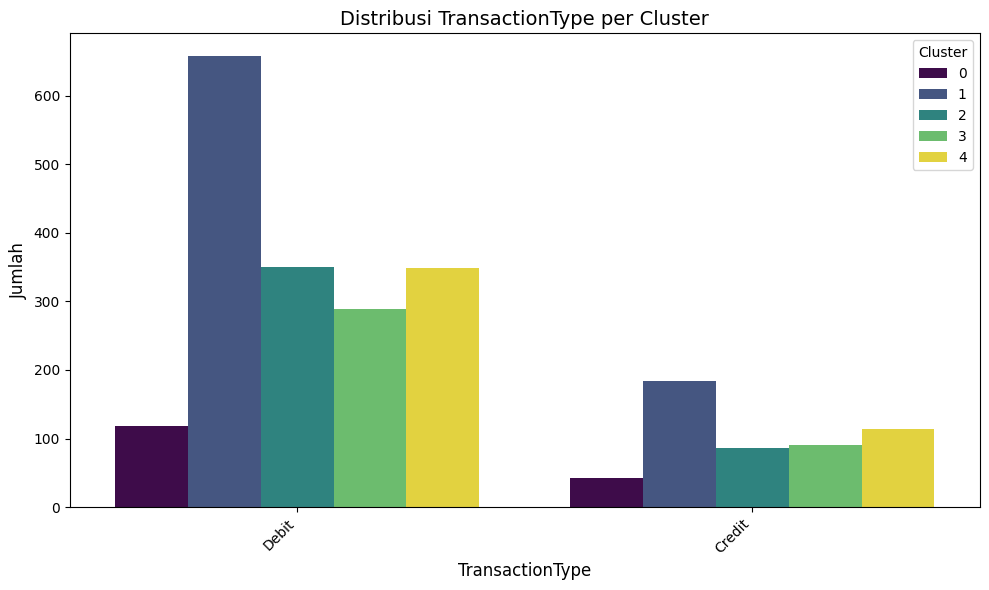

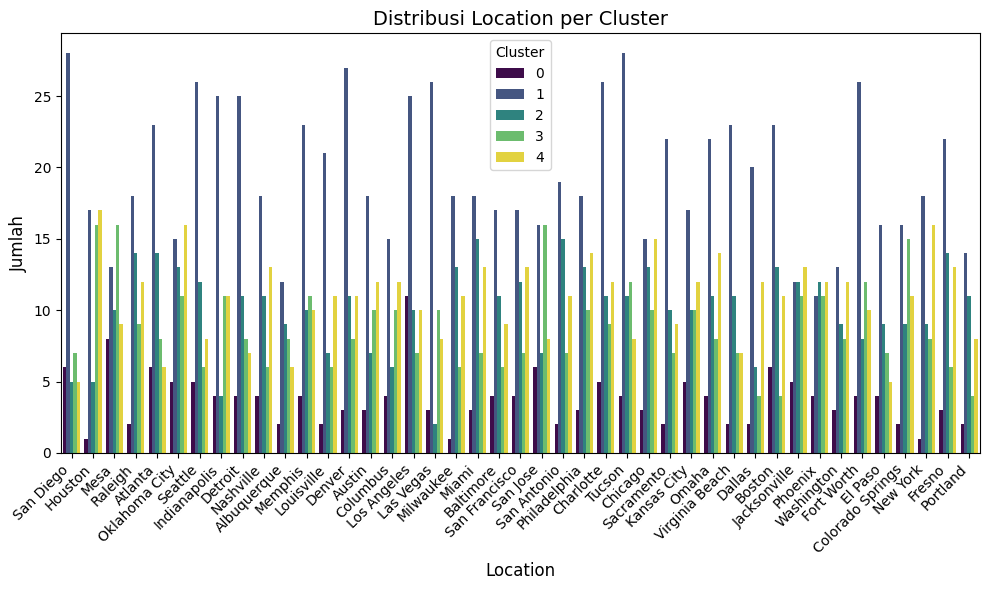

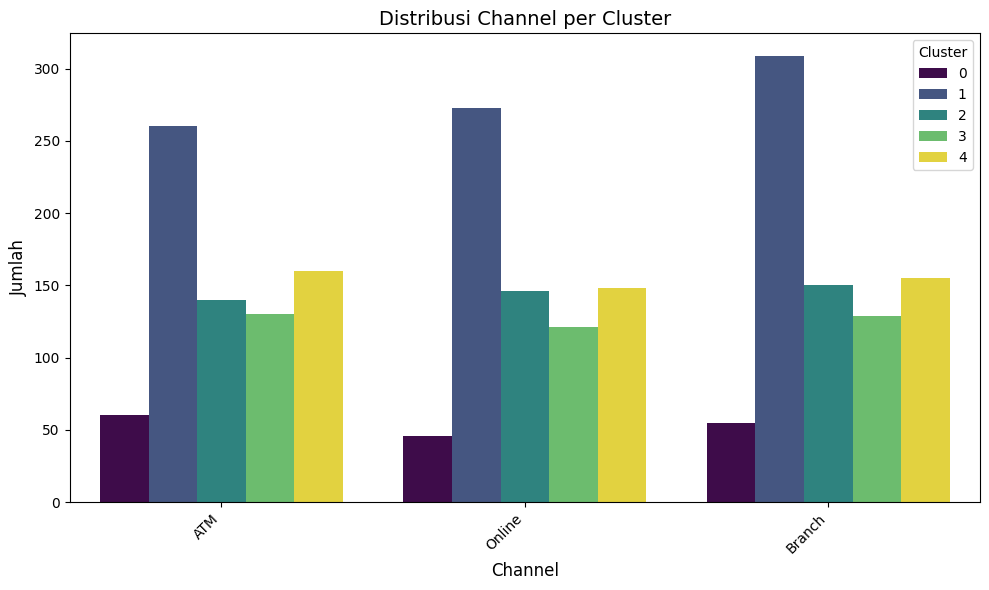

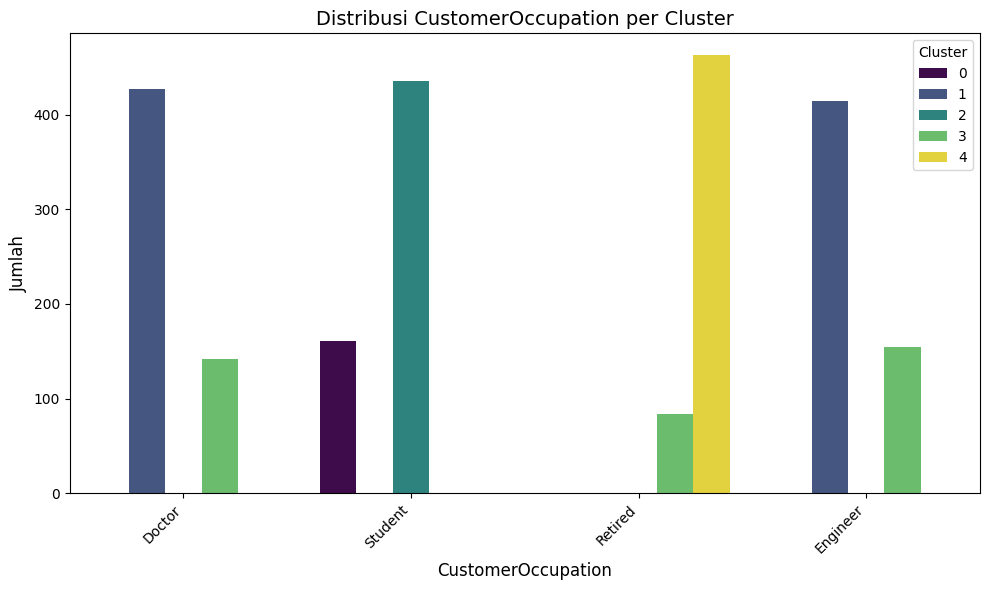

In [ ]:
# Statistik deskriptif per cluster
cluster_profile = df.groupby('Cluster').agg({
    'TransactionAmount': ['mean', 'median', 'min', 'max', 'std'],
    'AccountBalance': ['mean', 'median', 'min', 'max', 'std'],
    'TransactionDuration': ['mean', 'median', 'min', 'max', 'std'],
    'CustomerAge': ['mean', 'median', 'min', 'max', 'std'],
    'LoginAttempts': ['mean', 'median', 'min', 'max', 'std'],
    'TransactionType': lambda x: x.mode()[0],  # Modus TransactionType
    'Location': lambda x: x.mode()[0],        # Modus Location
    'Channel': lambda x: x.mode()[0],           # Modus Channel
    'CustomerOccupation': lambda x: x.mode()[0], # Modus CustomerOccupation
    'AgeGroup': lambda x: x.mode()[0]         # Modus AgeGroup
}).round(2)

print("Profil Cluster:")
display(cluster_profile)

# Visualisasi distribusi fitur per cluster
plt.figure(figsize=(15, 10))  # Ukuran figure lebih besar
for i, feature in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)  # Layout subplot 2 baris, 3 kolom
    sns.boxplot(x='Cluster', y=feature, data=df, hue='Cluster', palette="Set3", dodge=False)
    plt.title(f'Distribusi {feature} per Cluster', fontsize=12)  # Ukuran font judul
    plt.xlabel('Cluster', fontsize=10)  # Ukuran font label sumbu x
    plt.ylabel(feature, fontsize=10)  # Ukuran font label sumbu y
    plt.legend([],[], frameon=False)  # Menonaktifkan legenda
plt.tight_layout()  # Atur jarak antar subplot
plt.show()

# Visualisasi distribusi fitur kategorikal per cluster
for feature in categorical_cols:
    plt.figure(figsize=(10, 6))  # Ukuran figure
    sns.countplot(x=feature, hue='Cluster', data=df, palette="viridis")  # Palette warna
    plt.title(f'Distribusi {feature} per Cluster', fontsize=14)  # Ukuran font judul
    plt.xlabel(feature, fontsize=12)  # Ukuran font label sumbu x
    plt.ylabel('Jumlah', fontsize=12)  # Ukuran font label sumbu y
    plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotasi label sumbu x
    plt.legend(title='Cluster', fontsize=10)  # Legend dengan judul dan ukuran font
    plt.tight_layout()  # Atur jarak
    plt.show()

# Analisis Karakteristik Cluster dari Model KMeans
Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

# Cluster 0
* Rata-rata Transaction Amount: 587.62
* Rata-rata Account Balance: 1658.87
* Lokasi: Los Angeles
* Jenis Transaksi: Debit
* Channel: ATM
* Pekerjaan Pelanggan: Student
* Kelompok Usia: Young

Analisis: Cluster ini terdiri dari pelanggan muda (Young) yang mayoritas adalah mahasiswa. Mereka melakukan transaksi dengan nominal cukup besar melalui ATM, kemungkinan besar untuk kebutuhan pribadi atau akademik. Saldo akun mereka relatif rendah dibandingkan beberapa cluster lain.

# Cluster 1

* Rata-rata Transaction Amount: 143.60
* Rata-rata Account Balance: 7149.45
* Lokasi: San Diego
* Jenis Transaksi: Debit
* Channel: Branch
* Pekerjaan Pelanggan: Doctor
* Kelompok Usia: Middle-aged

Analisis: Cluster ini mencakup pelanggan usia menengah dengan pekerjaan sebagai dokter. Mereka memiliki saldo rekening yang cukup besar, tetapi jumlah transaksi rata-ratanya kecil. Hal ini menunjukkan mereka mungkin lebih memilih menyimpan uang dan hanya melakukan transaksi jika diperlukan.

# Cluster 2
* Rata-rata Transaction Amount: 150.54
* Rata-rata Account Balance: 1553.57
* Lokasi: Miami
* Jenis Transaksi: Debit
* Channel: Branch
* Pekerjaan Pelanggan: Student
* Kelompok Usia: Young

Analisis: Mirip dengan Cluster 0, pelanggan dalam kelompok ini adalah mahasiswa muda. Namun, mereka lebih sering bertransaksi di cabang bank dibandingkan ATM. Saldo akun mereka juga lebih rendah dibandingkan pelanggan di cluster lain, yang mungkin menunjukkan keterbatasan keuangan.

# Cluster 3
* Rata-rata Transaction Amount: 572.93
* Rata-rata Account Balance: 6788.05
* Lokasi: Houston
* Jenis Transaksi: Debit
* Channel: ATM
* Pekerjaan Pelanggan: Engineer
* Kelompok Usia: Senior

Analisis: Cluster ini terdiri dari pelanggan dengan pekerjaan sebagai insinyur dan berada dalam kelompok usia senior. Mereka memiliki saldo akun yang cukup tinggi dan sering melakukan transaksi dalam jumlah besar melalui ATM. Hal ini mungkin menunjukkan bahwa mereka masih aktif dalam dunia kerja dan memiliki keuangan yang stabil.

# Cluster 4
* Rata-rata Transaction Amount: 181.96
* Rata-rata Account Balance: 4620.05
* Lokasi: Houston
* Jenis Transaksi: Debit
* Channel: ATM
* Pekerjaan Pelanggan: Retired
* Kelompok Usia: Senior

Analisis: Cluster ini terdiri dari pelanggan yang sudah pensiun dan memiliki saldo rekening menengah. Transaksi yang mereka lakukan tidak terlalu besar, kemungkinan hanya untuk kebutuhan sehari-hari. Mereka lebih memilih menggunakan ATM dibandingkan cabang bank untuk bertransaksi.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [ ]:
df.to_csv('hasil_clustering.csv', index=False)